Accuracy: 0.7946

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      5266
           1       0.78      0.80      0.79      4734

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000


Saved tree image.


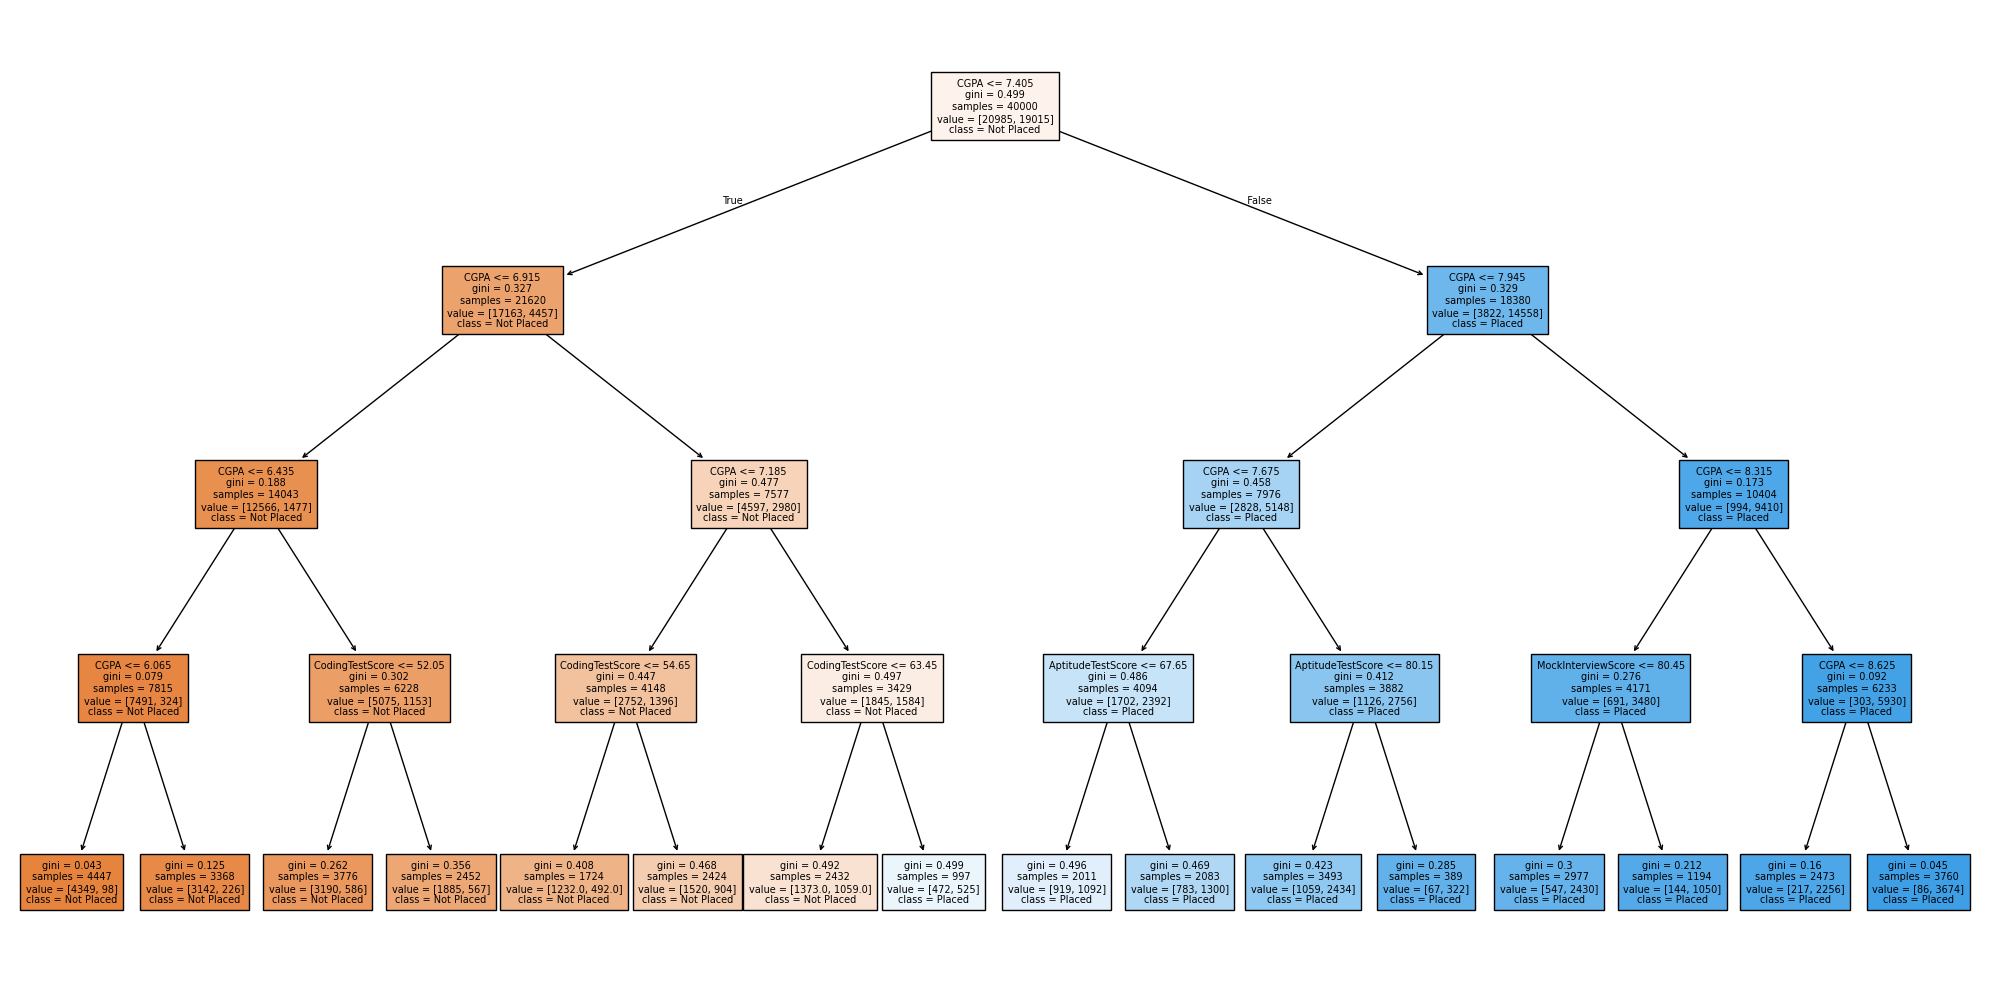

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv('placement_predict_50k_adjusted (1).csv')

# Remove anomaly column
df = df.drop(columns=['IsAnomaly'])


# Handle missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


# Convert categorical columns into numbers
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'City',
        'CollegeTier',
        'Stream',
        'Specialisation',
        'Hostel',
        'HistoryOfBacklogs',
        'ExtraCurricular'
    ],
    drop_first=True
)


# Features and target
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# Train
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Plot Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()

plt.savefig('decision_tree.png', dpi=150)

print("\nSaved tree image.")

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Random state
RANDOM_STATE = 42


# Load dataset
df = pd.read_csv("simple_placement_dataset.csv")


# Display dataset
print("Sample of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nClass balance:")
print(df["Placed"].value_counts())


# Target and columns to remove
TARGET = "Placed"

DROP_COLS = ["StudentID"]


# Select features
feature_names = [
    c for c in df.columns
    if c not in [TARGET] + DROP_COLS
]


X = df[feature_names].values
y = df[TARGET].values


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


# Create Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)


# Train model
rf.fit(X_train, y_train)


# Prediction
y_pred = rf.predict(X_test)


# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)


# Results
print("\nOOB score:", rf.oob_score_)

print("Test accuracy:", test_accuracy)


# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred))


# Feature importance
print("Feature importances:")

for name, importance in sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
   StudentID  CGPA  Internships  Projects  AptitudeTestScore  \
0          1  6.87            2         2                 57   
1          2  9.75            1         2                 95   
2          3  8.66            1         0                 71   
3          4  7.99            3         2                 74   
4          5  5.78            1         4                 91   

   CommunicationSkill  Placed  
0                   8       0  
1                   1       1  
2                   6       1  
3                   8       1  
4                   5       1  

Dataset shape:
(50, 7)

Class balance:
Placed
0    25
1    25
Name: count, dtype: int64

OOB score: 0.725
Test accuracy: 0.8

Classification report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.67      0.80         6

    accuracy                           0.80        10
   macro avg       0.83      0.8